In [1]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('/content/cleaned_data.csv') #using the data set cleaned in project 1 !
df.sample(10)

,OrderID,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,PricePerItem,CartUtilization,IsReferred
346,ORD200349,C39648,Chair,1,465.33,824 Main St,Gift Card,Delivered,TRK56016905,2,FREESHIP,Google,465.33,2023,11,30,465.33,0.500000,1
646,ORD200651,C81192,Chair,3,646.34,429 Main St,Debit Card,Pending,TRK76931118,5,No coupon,Google,1939.02,2024,11,12,646.34,0.600000,1
395,ORD200398,C50275,Phone,5,53.93,729 Main St,Gift Card,Shipped,TRK98925264,7,SAVE10,Instagram,269.65,2024,9,4,53.93,0.714286,1
538,ORD200542,C49726,Tablet,1,17.98,934 Main St,Cash,Cancelled,TRK20739460,6,FREESHIP,Email,17.98,2023,11,14,17.98,0.166667,1
148,ORD200149,C39671,Laptop,1,217.56,174 Main St,Debit Card,Delivered,TRK47153818,3,No coupon,Facebook,217.56,2023,12,27,217.56,0.333333,1
1009,ORD201015,C97454,Printer,2,349.40,892 Main St,Online,Shipped,TRK73249329,2,SAVE10,Instagram,698.80,2024,1,26,349.40,1.000000,1
296,ORD200297,C68078,Desk,2,493.88,252 Main St,Credit Card,Returned,TRK64862812,7,SAVE10,Instagram,987.76,2023,2,22,493.88,0.285714,1
450,ORD200453,C15017,Tablet,1,675.57,492 Main St,Cash,Shipped,TRK51241924,1,WINTER15,Facebook,675.57,2025,5,2,675.57,1.000000,1
1027,ORD201033,C20338,Monitor,1,370.85,331 Main St,Gift Card,Delivered,TRK30654048,2,FREESHIP,Referral,370.85,2024,12,24,370.85,0.500000,1
378,ORD200381,C29467,Chair,1,191.76,223 Main St,Credit Card,Returned,TRK98103385,1,FREESHIP,Instagram,191.76,2023,6,7,191.76,1.000000,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1192 entries, 0 to 1191
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1192 non-null   object 
 1   CustomerID       1192 non-null   object 
 2   Product          1192 non-null   object 
 3   Quantity         1192 non-null   int64  
 4   UnitPrice        1192 non-null   float64
 5   ShippingAddress  1192 non-null   object 
 6   PaymentMethod    1192 non-null   object 
 7   OrderStatus      1192 non-null   object 
 8   TrackingNumber   1192 non-null   object 
 9   ItemsInCart      1192 non-null   int64  
 10  CouponCode       1192 non-null   object 
 11  ReferralSource   1192 non-null   object 
 12  TotalPrice       1192 non-null   float64
 13  Year             1192 non-null   int64  
 14  Month            1192 non-null   int64  
 15  Day              1192 non-null   int64  
 16  PricePerItem     1192 non-null   float64
 17  CartUtilizatio

In [7]:
customer_df = df.groupby("CustomerID").agg({

    "OrderID":"nunique",
    "Quantity":"sum",
    "TotalPrice":"sum",
    "UnitPrice":"mean",
    "ItemsInCart":"mean",
    "PricePerItem":"mean",
    "CartUtilization":"mean",
    "IsReferred":"max",

    "PaymentMethod":lambda x:x.mode()[0], # to get the most frequent mode or transaction for a given customer.
    "ReferralSource":lambda x:x.mode()[0], # to get the most frequent referral source for a given customer.
    "OrderStatus":lambda x:x.mode()[0], # to get the most frequent order status for a given customer.
    "Product":"nunique"

}).reset_index()

In [23]:
customer_df

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,...,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct,Cluster
0,C10002,1,3,1470.03,490.01,4.0,490.01,0.750000,1,1,...,0,0,0,0,1,0,1470.03,3.0,1470.03,1
1,C10054,1,2,153.48,76.74,7.0,76.74,0.285714,1,1,...,0,0,0,0,1,0,153.48,2.0,153.48,0
2,C10126,1,2,1349.80,674.90,4.0,674.90,0.500000,1,1,...,0,0,0,0,0,1,1349.80,2.0,1349.80,3
3,C10154,1,4,1303.04,325.76,8.0,325.76,0.500000,1,1,...,0,0,0,0,0,1,1303.04,4.0,1303.04,0
4,C10211,1,5,635.90,127.18,10.0,127.18,0.500000,1,1,...,0,1,0,0,0,0,635.90,5.0,635.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,C99589,1,1,641.39,641.39,1.0,641.39,1.000000,1,1,...,1,1,0,0,0,0,641.39,1.0,641.39,3
1178,C99683,1,5,1663.20,332.64,10.0,332.64,0.500000,1,1,...,1,0,1,0,0,0,1663.20,5.0,1663.20,1
1179,C99775,1,4,1654.84,413.71,9.0,413.71,0.444444,1,1,...,0,1,0,0,0,0,1654.84,4.0,1654.84,1
1180,C99879,1,3,821.88,273.96,8.0,273.96,0.375000,1,1,...,0,0,0,0,1,0,821.88,3.0,821.88,0


In [8]:
customer_df.rename(columns={
    "OrderID":"TotalOrders",
    "Quantity":"TotalQuantity",
    "TotalPrice":"TotalSpent",
    "UnitPrice":"AverageUnitPrice",
    "ItemsInCart":"AverageCartSize",
    "Product":"UniqueProducts"
},inplace=True)

In [24]:
customer_df

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,...,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct,Cluster
0,C10002,1,3,1470.03,490.01,4.0,490.01,0.750000,1,1,...,0,0,0,0,1,0,1470.03,3.0,1470.03,1
1,C10054,1,2,153.48,76.74,7.0,76.74,0.285714,1,1,...,0,0,0,0,1,0,153.48,2.0,153.48,0
2,C10126,1,2,1349.80,674.90,4.0,674.90,0.500000,1,1,...,0,0,0,0,0,1,1349.80,2.0,1349.80,3
3,C10154,1,4,1303.04,325.76,8.0,325.76,0.500000,1,1,...,0,0,0,0,0,1,1303.04,4.0,1303.04,0
4,C10211,1,5,635.90,127.18,10.0,127.18,0.500000,1,1,...,0,1,0,0,0,0,635.90,5.0,635.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,C99589,1,1,641.39,641.39,1.0,641.39,1.000000,1,1,...,1,1,0,0,0,0,641.39,1.0,641.39,3
1178,C99683,1,5,1663.20,332.64,10.0,332.64,0.500000,1,1,...,1,0,1,0,0,0,1663.20,5.0,1663.20,1
1179,C99775,1,4,1654.84,413.71,9.0,413.71,0.444444,1,1,...,0,1,0,0,0,0,1654.84,4.0,1654.84,1
1180,C99879,1,3,821.88,273.96,8.0,273.96,0.375000,1,1,...,0,0,0,0,1,0,821.88,3.0,821.88,0


In [9]:
customer_df = pd.get_dummies(
    customer_df,columns=["PaymentMethod","ReferralSource","OrderStatus"], dtype=int)

In [25]:
customer_df

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,...,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct,Cluster
0,C10002,1,3,1470.03,490.01,4.0,490.01,0.750000,1,1,...,0,0,0,0,1,0,1470.03,3.0,1470.03,1
1,C10054,1,2,153.48,76.74,7.0,76.74,0.285714,1,1,...,0,0,0,0,1,0,153.48,2.0,153.48,0
2,C10126,1,2,1349.80,674.90,4.0,674.90,0.500000,1,1,...,0,0,0,0,0,1,1349.80,2.0,1349.80,3
3,C10154,1,4,1303.04,325.76,8.0,325.76,0.500000,1,1,...,0,0,0,0,0,1,1303.04,4.0,1303.04,0
4,C10211,1,5,635.90,127.18,10.0,127.18,0.500000,1,1,...,0,1,0,0,0,0,635.90,5.0,635.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,C99589,1,1,641.39,641.39,1.0,641.39,1.000000,1,1,...,1,1,0,0,0,0,641.39,1.0,641.39,3
1178,C99683,1,5,1663.20,332.64,10.0,332.64,0.500000,1,1,...,1,0,1,0,0,0,1663.20,5.0,1663.20,1
1179,C99775,1,4,1654.84,413.71,9.0,413.71,0.444444,1,1,...,0,1,0,0,0,0,1654.84,4.0,1654.84,1
1180,C99879,1,3,821.88,273.96,8.0,273.96,0.375000,1,1,...,0,0,0,0,1,0,821.88,3.0,821.88,0


In [10]:
customer_df["AverageOrderValue"] = (customer_df["TotalSpent"] /customer_df["TotalOrders"])

In [26]:
customer_df

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,...,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct,Cluster
0,C10002,1,3,1470.03,490.01,4.0,490.01,0.750000,1,1,...,0,0,0,0,1,0,1470.03,3.0,1470.03,1
1,C10054,1,2,153.48,76.74,7.0,76.74,0.285714,1,1,...,0,0,0,0,1,0,153.48,2.0,153.48,0
2,C10126,1,2,1349.80,674.90,4.0,674.90,0.500000,1,1,...,0,0,0,0,0,1,1349.80,2.0,1349.80,3
3,C10154,1,4,1303.04,325.76,8.0,325.76,0.500000,1,1,...,0,0,0,0,0,1,1303.04,4.0,1303.04,0
4,C10211,1,5,635.90,127.18,10.0,127.18,0.500000,1,1,...,0,1,0,0,0,0,635.90,5.0,635.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,C99589,1,1,641.39,641.39,1.0,641.39,1.000000,1,1,...,1,1,0,0,0,0,641.39,1.0,641.39,3
1178,C99683,1,5,1663.20,332.64,10.0,332.64,0.500000,1,1,...,1,0,1,0,0,0,1663.20,5.0,1663.20,1
1179,C99775,1,4,1654.84,413.71,9.0,413.71,0.444444,1,1,...,0,1,0,0,0,0,1654.84,4.0,1654.84,1
1180,C99879,1,3,821.88,273.96,8.0,273.96,0.375000,1,1,...,0,0,0,0,1,0,821.88,3.0,821.88,0


In [11]:
customer_df["AverageQuantityPerOrder"] = (customer_df["TotalQuantity"] /customer_df["TotalOrders"])

In [27]:
customer_df

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,...,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct,Cluster
0,C10002,1,3,1470.03,490.01,4.0,490.01,0.750000,1,1,...,0,0,0,0,1,0,1470.03,3.0,1470.03,1
1,C10054,1,2,153.48,76.74,7.0,76.74,0.285714,1,1,...,0,0,0,0,1,0,153.48,2.0,153.48,0
2,C10126,1,2,1349.80,674.90,4.0,674.90,0.500000,1,1,...,0,0,0,0,0,1,1349.80,2.0,1349.80,3
3,C10154,1,4,1303.04,325.76,8.0,325.76,0.500000,1,1,...,0,0,0,0,0,1,1303.04,4.0,1303.04,0
4,C10211,1,5,635.90,127.18,10.0,127.18,0.500000,1,1,...,0,1,0,0,0,0,635.90,5.0,635.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,C99589,1,1,641.39,641.39,1.0,641.39,1.000000,1,1,...,1,1,0,0,0,0,641.39,1.0,641.39,3
1178,C99683,1,5,1663.20,332.64,10.0,332.64,0.500000,1,1,...,1,0,1,0,0,0,1663.20,5.0,1663.20,1
1179,C99775,1,4,1654.84,413.71,9.0,413.71,0.444444,1,1,...,0,1,0,0,0,0,1654.84,4.0,1654.84,1
1180,C99879,1,3,821.88,273.96,8.0,273.96,0.375000,1,1,...,0,0,0,0,1,0,821.88,3.0,821.88,0


In [12]:
customer_df["SpendPerProduct"] = (customer_df["TotalSpent"] /customer_df["UniqueProducts"])

In [28]:
customer_df

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,...,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct,Cluster
0,C10002,1,3,1470.03,490.01,4.0,490.01,0.750000,1,1,...,0,0,0,0,1,0,1470.03,3.0,1470.03,1
1,C10054,1,2,153.48,76.74,7.0,76.74,0.285714,1,1,...,0,0,0,0,1,0,153.48,2.0,153.48,0
2,C10126,1,2,1349.80,674.90,4.0,674.90,0.500000,1,1,...,0,0,0,0,0,1,1349.80,2.0,1349.80,3
3,C10154,1,4,1303.04,325.76,8.0,325.76,0.500000,1,1,...,0,0,0,0,0,1,1303.04,4.0,1303.04,0
4,C10211,1,5,635.90,127.18,10.0,127.18,0.500000,1,1,...,0,1,0,0,0,0,635.90,5.0,635.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,C99589,1,1,641.39,641.39,1.0,641.39,1.000000,1,1,...,1,1,0,0,0,0,641.39,1.0,641.39,3
1178,C99683,1,5,1663.20,332.64,10.0,332.64,0.500000,1,1,...,1,0,1,0,0,0,1663.20,5.0,1663.20,1
1179,C99775,1,4,1654.84,413.71,9.0,413.71,0.444444,1,1,...,0,1,0,0,0,0,1654.84,4.0,1654.84,1
1180,C99879,1,3,821.88,273.96,8.0,273.96,0.375000,1,1,...,0,0,0,0,1,0,821.88,3.0,821.88,0


In [13]:
X = customer_df.drop(columns=["CustomerID"])

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [16]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2","PC3"])

In [18]:
print(pca.explained_variance_ratio_)
print("Total Variance =",pca.explained_variance_ratio_.sum())

[0.19607364 0.09166845 0.07169754]
Total Variance = 0.35943962622451264


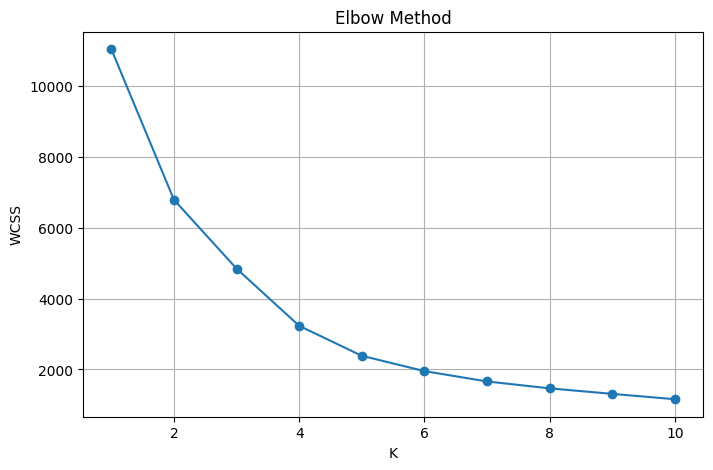

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss=[]
for k in range(1,11):
    model=KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(pca_df)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    model=KMeans(n_clusters=k, random_state=42,n_init=10)
    labels=model.fit_predict(pca_df)
    score=silhouette_score(pca_df,labels)
    print(f"K={k} Score={score:.4f}")

K=2 Score=0.4013
K=3 Score=0.4158
K=4 Score=0.4022
K=5 Score=0.3955
K=6 Score=0.3677
K=7 Score=0.3653
K=8 Score=0.3694
K=9 Score=0.3655
K=10 Score=0.3592


In [21]:
kmeans=KMeans(n_clusters=4, random_state=42,n_init=10)
clusters=kmeans.fit_predict(pca_df)
customer_df["Cluster"]=clusters
pca_df["Cluster"]=clusters

In [22]:
pca_df

,PC1,PC2,PC3,Cluster
0,1.031378,-0.982332,0.114006,1
1,-2.754953,1.021810,-0.598710,0
2,0.863707,-2.787785,0.379125,3
3,0.990048,0.951614,-0.733285,0
4,-0.087433,3.127605,-1.265761,0
...,...,...,...,...
1177,-0.896867,-3.133888,0.954332,3
1178,2.202057,1.581523,-1.119563,1
1179,1.969865,0.537795,-0.570521,1
1180,-0.577058,0.614191,-0.750284,0


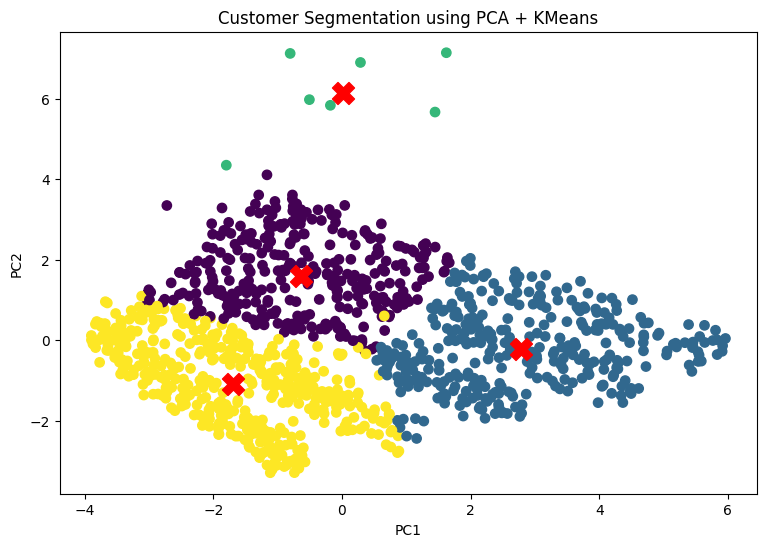

In [29]:
plt.figure(figsize=(9,6))

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=clusters, cmap="viridis", s=45)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color="red",marker="X", s=250)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using PCA + KMeans")
plt.show()

In [37]:
customer_df

,CustomerID,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,...,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct,Cluster
0,C10002,1,3,1470.03,490.01,4.0,490.01,0.750000,1,1,...,0,0,0,0,1,0,1470.03,3.0,1470.03,1
1,C10054,1,2,153.48,76.74,7.0,76.74,0.285714,1,1,...,0,0,0,0,1,0,153.48,2.0,153.48,0
2,C10126,1,2,1349.80,674.90,4.0,674.90,0.500000,1,1,...,0,0,0,0,0,1,1349.80,2.0,1349.80,3
3,C10154,1,4,1303.04,325.76,8.0,325.76,0.500000,1,1,...,0,0,0,0,0,1,1303.04,4.0,1303.04,0
4,C10211,1,5,635.90,127.18,10.0,127.18,0.500000,1,1,...,0,1,0,0,0,0,635.90,5.0,635.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1177,C99589,1,1,641.39,641.39,1.0,641.39,1.000000,1,1,...,1,1,0,0,0,0,641.39,1.0,641.39,3
1178,C99683,1,5,1663.20,332.64,10.0,332.64,0.500000,1,1,...,1,0,1,0,0,0,1663.20,5.0,1663.20,1
1179,C99775,1,4,1654.84,413.71,9.0,413.71,0.444444,1,1,...,0,1,0,0,0,0,1654.84,4.0,1654.84,1
1180,C99879,1,3,821.88,273.96,8.0,273.96,0.375000,1,1,...,0,0,0,0,1,0,821.88,3.0,821.88,0


In [32]:
cluster_size = customer_df['Cluster'].value_counts().sort_index()
cluster_size # to get the number of data belonging to each clusters

,count
Cluster,
0,338
1,363
2,7
3,474


In [33]:
cluster_percentage = (customer_df['Cluster'].value_counts(normalize=True).sort_index()* 100)
cluster_percentage # getting percentage of data in each clusters!

,proportion
Cluster,
0,28.595601
1,30.710660
2,0.592217
3,40.101523


In [34]:
cluster_summary = customer_df.groupby("Cluster").mean(numeric_only=True)
cluster_summary = cluster_summary.round(2)
cluster_summary

,TotalOrders,TotalQuantity,TotalSpent,AverageUnitPrice,AverageCartSize,PricePerItem,CartUtilization,IsReferred,UniqueProducts,PaymentMethod_Cash,...,ReferralSource_Instagram,ReferralSource_Referral,OrderStatus_Cancelled,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,AverageOrderValue,AverageQuantityPerOrder,SpendPerProduct
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.0,3.84,673.11,177.61,6.54,177.61,0.63,1.0,1.0,0.25,...,0.20,0.17,0.21,0.23,0.21,0.18,0.17,672.82,3.83,673.11
1,1.0,3.99,2068.22,524.54,6.60,524.54,0.65,1.0,1.0,0.20,...,0.21,0.18,0.23,0.18,0.22,0.19,0.18,2064.29,3.98,2068.22
2,2.0,5.71,1298.43,246.85,5.00,246.85,0.60,1.0,2.0,0.29,...,0.29,0.14,0.29,0.14,0.57,0.00,0.00,649.21,2.86,649.21
3,1.0,1.50,528.19,352.86,3.87,352.86,0.49,1.0,1.0,0.18,...,0.22,0.20,0.20,0.18,0.17,0.24,0.22,526.43,1.49,528.19


In [35]:
cluster_summary.to_csv("Cluster_Summary.csv")

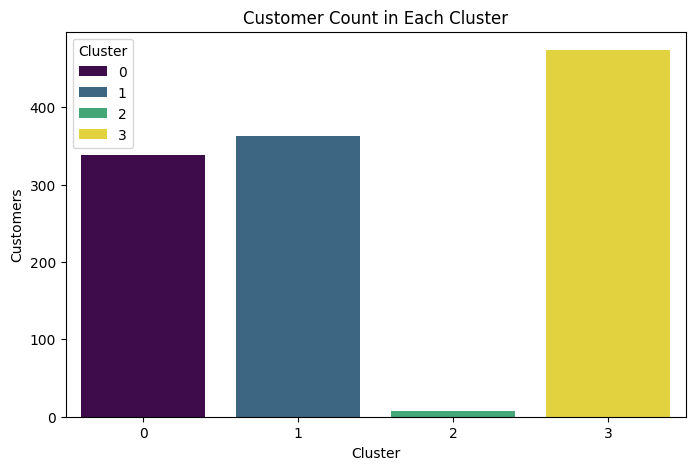

In [38]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="Cluster",data=customer_df,palette="viridis", hue='Cluster')
plt.title("Customer Count in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.show()

/tmp/ipykernel_846/3794071563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index,y=cluster_summary["TotalSpent"],palette="viridis")


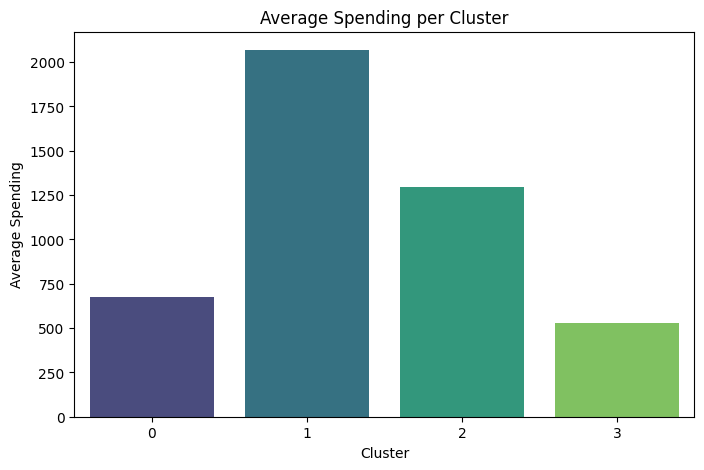

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_summary.index,y=cluster_summary["TotalSpent"],palette="viridis")
plt.title("Average Spending per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending")
plt.show()

/tmp/ipykernel_846/1597508681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index,y=cluster_summary["TotalOrders"],palette="viridis")


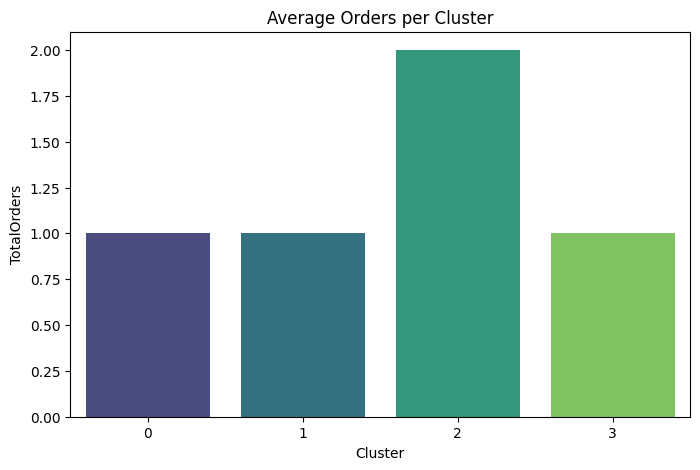

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_summary.index,y=cluster_summary["TotalOrders"],palette="viridis")
plt.title("Average Orders per Cluster")
plt.show()

/tmp/ipykernel_846/816594209.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index,y=cluster_summary["TotalQuantity"],palette="viridis")


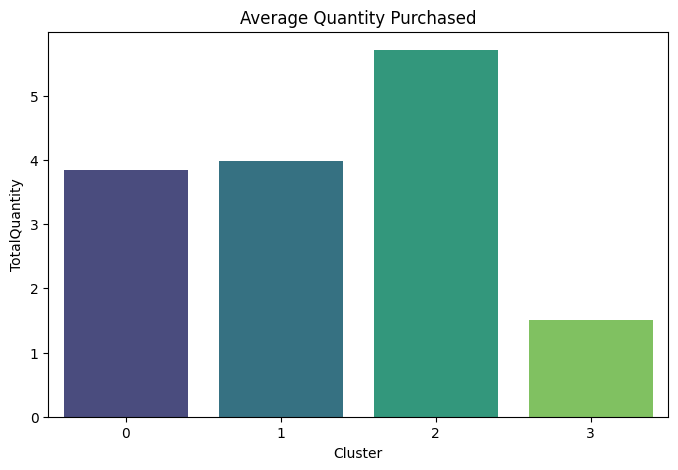

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_summary.index,y=cluster_summary["TotalQuantity"],palette="viridis")
plt.title("Average Quantity Purchased")
plt.show()

/tmp/ipykernel_846/3356224710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary["AverageCartSize"], palette="viridis")


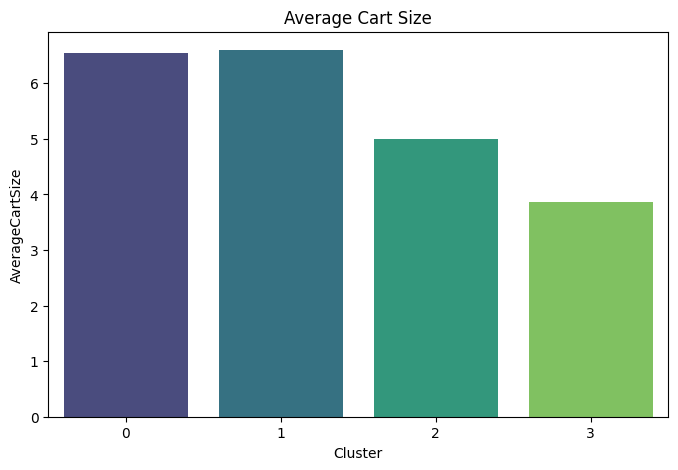

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_summary.index, y=cluster_summary["AverageCartSize"], palette="viridis")
plt.title("Average Cart Size")
plt.show()

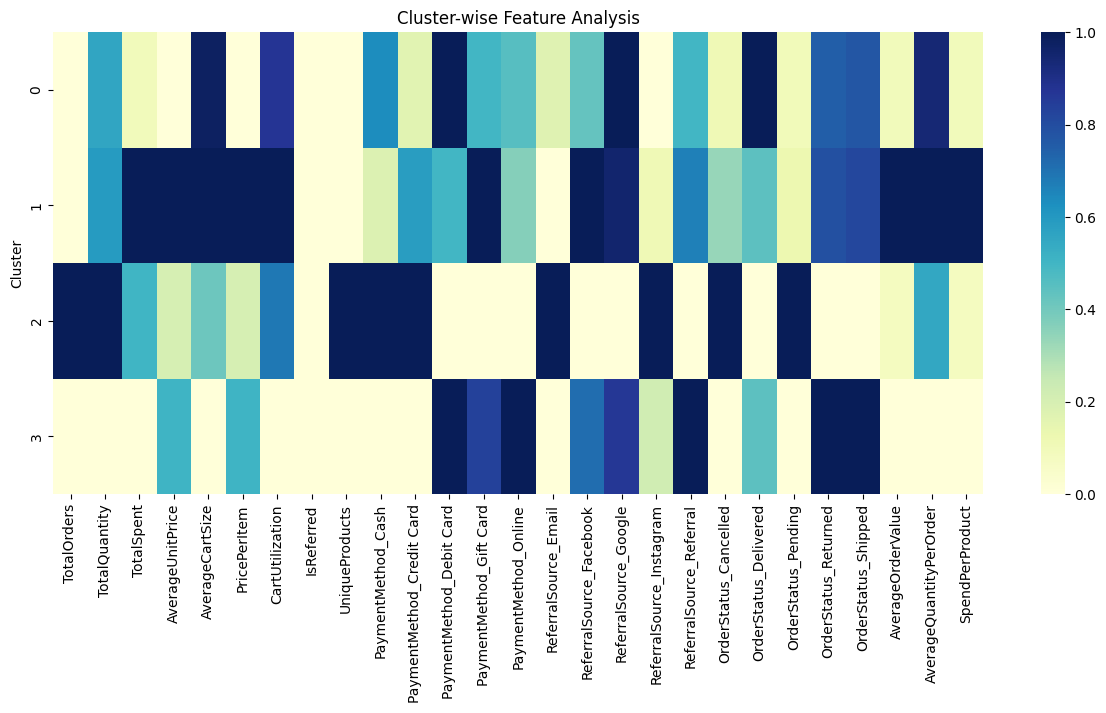

In [48]:
from sklearn.preprocessing import MinMaxScaler

scaled = MinMaxScaler().fit_transform(cluster_summary)
scaled = pd.DataFrame(scaled,columns=cluster_summary.columns,index=cluster_summary.index)
plt.figure(figsize=(15,6))

sns.heatmap(scaled,cmap="YlGnBu",annot=False)
plt.title("Cluster-wise Feature Analysis")
plt.show()

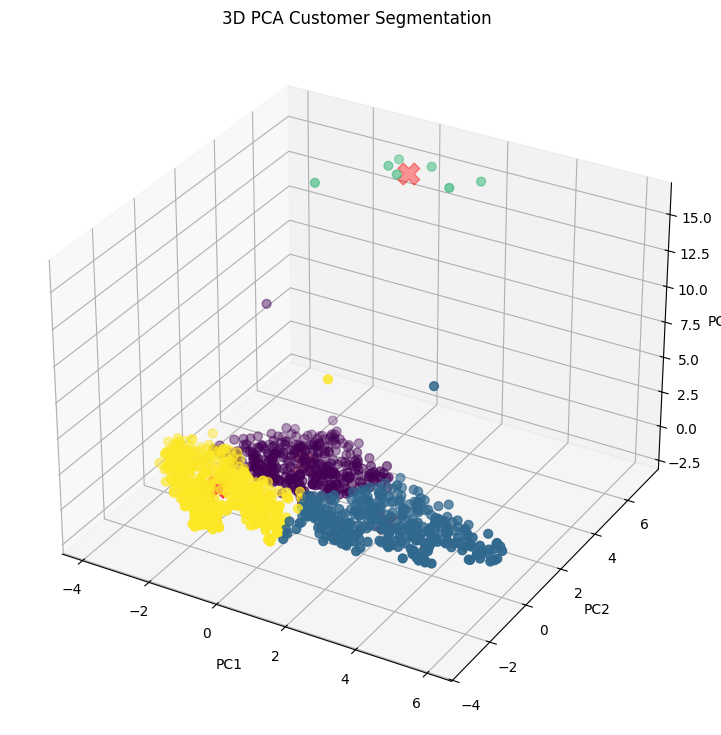

In [54]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 9))

ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(pca_df["PC1"],pca_df["PC2"],pca_df["PC3"],c=pca_df["Cluster"],cmap="viridis",s=40)

ax.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],kmeans.cluster_centers_[:,2],c="red",s=250,marker="X")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Customer Segmentation")
plt.show() # resulting PCA in 3-Dimensional for clear Distinction

In [50]:
customer_df.to_csv("Customer_Segmentation_Result.csv",index=False)